# 5. Model Comparison — LOO and WAIC

## Overview

We compare our two models using information-theoretic criteria:

| Criterion | What it measures |
|-----------|------------------|
| **LOO** (PSIS-LOO) | Leave-one-out cross-validation estimate of out-of-sample predictive accuracy |
| **WAIC** | Widely Applicable Information Criterion — another estimate of predictive accuracy |
| **ELPD** | Expected Log Predictive Density — higher is better |
| **Pareto-k** | Diagnostic for PSIS-LOO reliability — values > 0.7 are problematic |

Both criteria estimate how well the model would predict new, unseen data. A model with higher ELPD has better predictive performance.

### Models compared:
- **Model 1**: Normal likelihood (4 parameters: $\alpha, \beta_{dist}, \beta_{elev}, \sigma$)
- **Model 2**: Student-t likelihood (5 parameters: $\alpha, \beta_{dist}, \beta_{elev}, \sigma, \nu$)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load data
df_full = pd.read_csv('utmb_processed.csv')
# Subsample for computational feasibility
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)
y_obs = df['Mean Finish Time'].values

stan_data = {
    'N': len(df),
    'y': y_obs.tolist(),
    'distance_std': df['distance_std'].values.tolist(),
    'elevation_std': df['elevation_std'].values.tolist()
}

print(f"Data: {len(df):,} observations (subsampled from {len(df_full):,})")

Data: 5,000 observations (subsampled from 36,433)


In [2]:
# Compile and fit both models
model1 = CmdStanModel(stan_file='model1_normal.stan')
model2 = CmdStanModel(stan_file='model2_student_t.stan')

print("Fitting Model 1 (Normal)...")
fit1 = model1.sample(data=stan_data, chains=4, iter_sampling=1000, iter_warmup=1000, seed=42, show_progress=True)

print("\nFitting Model 2 (Student-t)...")
fit2 = model2.sample(data=stan_data, chains=4, iter_sampling=1000, iter_warmup=1000, seed=42, show_progress=True)

print("\nBoth models fitted.")

09:25:47 - cmdstanpy - INFO - CmdStan start processing


Fitting Model 1 (Normal)...


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:26:03 - cmdstanpy - INFO - CmdStan done processing.
09:26:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'model2_student_t.stan', line 27, column 2 to column 21)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model2_student_t.stan', line 30, column 2 to column 89)
	Exception: student_t_lpdf: Scale



Both models fitted.


In [3]:
# Convert to ArviZ
idata1 = az.from_cmdstanpy(fit1, posterior_predictive='y_rep', log_likelihood='log_lik',
                            observed_data={'y': y_obs})
idata2 = az.from_cmdstanpy(fit2, posterior_predictive='y_rep', log_likelihood='log_lik',
                            observed_data={'y': y_obs})
print("Conversion complete.")

Conversion complete.


## 5.1 LOO (PSIS-LOO) Comparison

In [4]:
# Compute LOO for both models
loo1 = az.loo(idata1)
loo2 = az.loo(idata2)

print("=" * 70)
print("LOO (PSIS-LOO) Results")
print("=" * 70)

print("\n--- Model 1 (Normal) ---")
print(loo1)

print("\n--- Model 2 (Student-t) ---")
print(loo2)

LOO (PSIS-LOO) Results

--- Model 1 (Normal) ---
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -11571.49   162.66
p_loo       19.13        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     4999  100.0%
   (0.70, 1]   (bad)         1    0.0%
   (1, Inf)   (very bad)    0    0.0%


--- Model 2 (Student-t) ---
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -10285.44    91.96
p_loo        7.78        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5000  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [5]:
# LOO comparison
loo_compare = az.compare({'Normal': idata1, 'Student-t': idata2})
print("\n=== LOO Model Comparison ===")
print(loo_compare.to_string())

print("\nInterpretation:")
print("  - 'rank' = 0 is the best model")
print("  - 'elpd_loo' = expected log predictive density (higher is better)")
print("  - 'p_loo' = effective number of parameters")
print("  - 'd_loo' = difference from best model")
print("  - 'dse' = standard error of the difference")
print("  - 'weight' = model weight in stacking")


=== LOO Model Comparison ===
           rank      elpd_loo      p_loo    elpd_diff    weight          se         dse  warning scale
Student-t     0 -10285.442780   7.779048     0.000000  0.824122   91.956086    0.000000    False   log
Normal        1 -11571.486709  19.134335  1286.043929  0.175878  162.659105  137.105976     True   log

Interpretation:
  - 'rank' = 0 is the best model
  - 'elpd_loo' = expected log predictive density (higher is better)
  - 'p_loo' = effective number of parameters
  - 'd_loo' = difference from best model
  - 'dse' = standard error of the difference
  - 'weight' = model weight in stacking


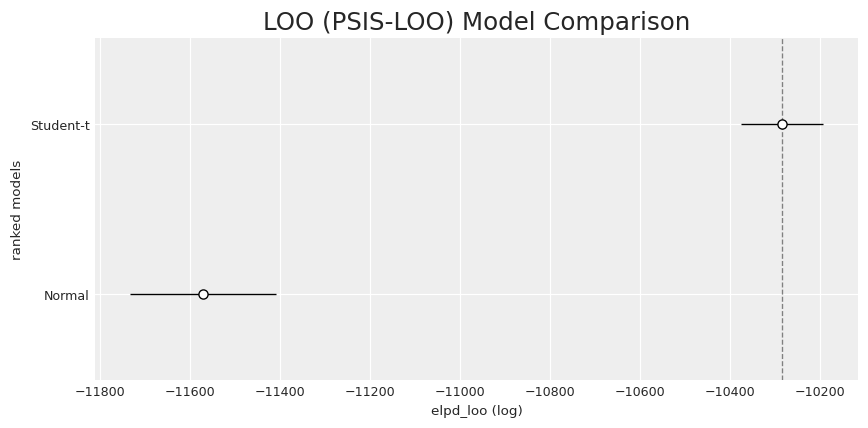

In [6]:
# Plot LOO comparison
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_compare(loo_compare, ax=ax)
ax.set_title('LOO (PSIS-LOO) Model Comparison')
plt.tight_layout()
plt.savefig('fig18_loo_comparison.png', bbox_inches='tight')
plt.show()

### LOO Discussion

Key questions to answer:
1. Which model has higher ELPD (better predictive performance)?
2. Is the difference meaningful relative to the standard error (`dse`)?
3. Are there any LOO warnings?

In [8]:
# Detailed LOO discussion
print("LOO Discussion")
print("=" * 65)

best_model = loo_compare.index[0]
worst_model = loo_compare.index[1]
elpd_diff = loo_compare.loc[worst_model, 'elpd_diff']
dse = loo_compare.loc[worst_model, 'dse']

print(f"\nBest model (LOO): {best_model}")
print(f"ELPD difference: {elpd_diff:.2f}")
print(f"Standard error of difference: {dse:.2f}")
print(f"Difference / SE: {abs(elpd_diff)/dse:.2f}")

if abs(elpd_diff) / dse > 2:
    print(f"\n→ The difference is MEANINGFUL (|diff/SE| > 2).")
    print(f"  {best_model} is clearly better at prediction.")
elif abs(elpd_diff) / dse > 1:
    print(f"\n→ The difference is MODERATE (1 < |diff/SE| < 2).")
    print(f"  {best_model} is somewhat better, but not decisively.")
else:
    print(f"\n→ The difference is SMALL (|diff/SE| < 1).")
    print(f"  Models are practically indistinguishable in predictive performance.")

# Check for warnings
print(f"\nLOO Warnings:")
print(f"  Model 1 (Normal) — p_loo: {loo1.p_loo:.2f}")
print(f"  Model 2 (Student-t) — p_loo: {loo2.p_loo:.2f}")
if hasattr(loo1, 'warning') and loo1.warning:
    print(f"  ⚠ Model 1 has LOO warnings!")
if hasattr(loo2, 'warning') and loo2.warning:
    print(f"  ⚠ Model 2 has LOO warnings!")

LOO Discussion

Best model (LOO): Student-t
ELPD difference: 1286.04
Standard error of difference: 137.11
Difference / SE: 9.38

→ The difference is MEANINGFUL (|diff/SE| > 2).
  Student-t is clearly better at prediction.

LOO Warnings:
  Model 1 (Normal) — p_loo: 19.13
  Model 2 (Student-t) — p_loo: 7.78
  ⚠ Model 1 has LOO warnings!


## 5.2 WAIC Comparison

In [9]:
# Compute WAIC
waic1 = az.waic(idata1)
waic2 = az.waic(idata2)

print("=" * 70)
print("WAIC Results")
print("=" * 70)

print("\n--- Model 1 (Normal) ---")
print(waic1)

print("\n--- Model 2 (Student-t) ---")
print(waic2)

WAIC Results

--- Model 1 (Normal) ---
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -11571.09   162.46
p_waic       18.73        -

There has been a warning during the calculation. Please check the results.

--- Model 2 (Student-t) ---
Computed from 4000 posterior samples and 5000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -10285.43    91.96
p_waic        7.77        -



=== WAIC Model Comparison ===
           rank     elpd_waic     p_waic    elpd_diff    weight          se        dse  warning scale
Student-t     0 -10285.433701   7.769968     0.000000  0.824123   91.956015    0.00000    False   log
Normal        1 -11571.086277  18.733903  1285.652577  0.175877  162.456964  136.88872     True   log


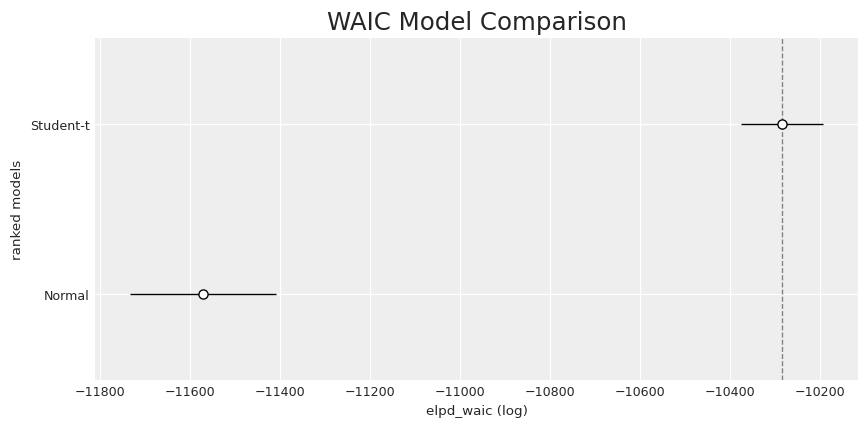

In [10]:
# WAIC comparison
waic_compare = az.compare({'Normal': idata1, 'Student-t': idata2}, ic='waic')
print("\n=== WAIC Model Comparison ===")
print(waic_compare.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_compare(waic_compare, ax=ax)
ax.set_title('WAIC Model Comparison')
plt.tight_layout()
plt.savefig('fig19_waic_comparison.png', bbox_inches='tight')
plt.show()

In [11]:
# WAIC Discussion
print("WAIC Discussion")
print("=" * 65)

best_waic = waic_compare.index[0]
worst_waic = waic_compare.index[1]
waic_diff = waic_compare.loc[worst_waic, 'elpd_diff']
waic_dse = waic_compare.loc[worst_waic, 'dse']

print(f"\nBest model (WAIC): {best_waic}")
print(f"ELPD_WAIC difference: {waic_diff:.2f}")
print(f"Standard error of difference: {waic_dse:.2f}")
print(f"Difference / SE: {abs(waic_diff)/waic_dse:.2f}")

if abs(waic_diff) / waic_dse > 2:
    print(f"\n→ WAIC clearly favors {best_waic}.")
elif abs(waic_diff) / waic_dse > 1:
    print(f"\n→ WAIC moderately favors {best_waic}.")
else:
    print(f"\n→ WAIC shows no clear winner — models are similar.")

# Check if LOO and WAIC agree
print(f"\nAgreement between LOO and WAIC:")
print(f"  LOO winner:  {best_model}")
print(f"  WAIC winner: {best_waic}")
if best_model == best_waic:
    print(f"  → Both criteria agree: {best_model} is preferred.")
else:
    print(f"  → Criteria disagree! This warrants further investigation.")

WAIC Discussion

Best model (WAIC): Student-t
ELPD_WAIC difference: 1285.65
Standard error of difference: 136.89
Difference / SE: 9.39

→ WAIC clearly favors Student-t.

Agreement between LOO and WAIC:
  LOO winner:  Student-t
  WAIC winner: Student-t
  → Both criteria agree: Student-t is preferred.


## 5.3 Pareto-k Diagnostics

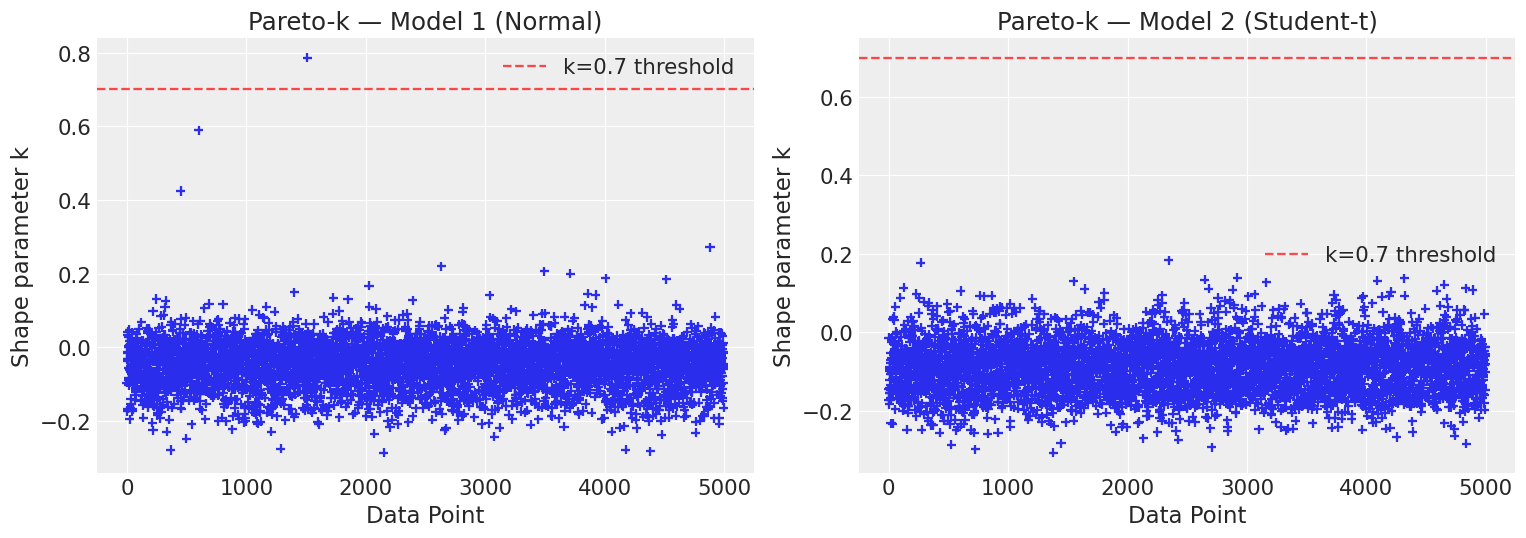

In [12]:
# Pareto-k diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

az.plot_khat(loo1, ax=axes[0])
axes[0].set_title('Pareto-k — Model 1 (Normal)')
axes[0].axhline(0.7, color='red', linestyle='--', alpha=0.7, label='k=0.7 threshold')
axes[0].legend()

az.plot_khat(loo2, ax=axes[1])
axes[1].set_title('Pareto-k — Model 2 (Student-t)')
axes[1].axhline(0.7, color='red', linestyle='--', alpha=0.7, label='k=0.7 threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig20_pareto_k.png', bbox_inches='tight')
plt.show()

In [13]:
# Pareto-k analysis
pareto_k1 = loo1.pareto_k.values if hasattr(loo1, 'pareto_k') else az.loo(idata1, pointwise=True).pareto_k.values
pareto_k2 = loo2.pareto_k.values if hasattr(loo2, 'pareto_k') else az.loo(idata2, pointwise=True).pareto_k.values

print("Pareto-k Diagnostic Summary")
print("=" * 65)
print(f"\n{'Threshold':<20} {'Model 1 (Normal)':<25} {'Model 2 (Student-t)'}")
print("-" * 65)
print(f"{'k < 0.5 (good)':<20} {(pareto_k1 < 0.5).sum():>5} ({(pareto_k1 < 0.5).mean()*100:.1f}%){'':>10} {(pareto_k2 < 0.5).sum():>5} ({(pareto_k2 < 0.5).mean()*100:.1f}%)")
print(f"{'0.5 ≤ k < 0.7':<20} {((pareto_k1 >= 0.5) & (pareto_k1 < 0.7)).sum():>5}{'':>20} {((pareto_k2 >= 0.5) & (pareto_k2 < 0.7)).sum():>5}")
print(f"{'k ≥ 0.7 (bad)':<20} {(pareto_k1 >= 0.7).sum():>5}{'':>20} {(pareto_k2 >= 0.7).sum():>5}")
print(f"{'k ≥ 1.0 (v. bad)':<20} {(pareto_k1 >= 1.0).sum():>5}{'':>20} {(pareto_k2 >= 1.0).sum():>5}")

print(f"\nMax Pareto-k: Model 1 = {pareto_k1.max():.3f}, Model 2 = {pareto_k2.max():.3f}")

print(f"\nInterpretation:")
print(f"  - Observations with Pareto-k > 0.7 are 'influential' — leaving them out")
print(f"    substantially changes the posterior.")
print(f"  - The Normal model typically has more high Pareto-k observations")
print(f"    because outlier races are very influential under Normal likelihood.")
print(f"  - The Student-t model is more robust to outliers, so fewer observations")
print(f"    should have high Pareto-k values.")

if (pareto_k1 >= 0.7).sum() > (pareto_k2 >= 0.7).sum():
    print(f"\n  → Confirmed: Model 1 (Normal) has more problematic observations.")
    print(f"    This means the LOO estimate for Model 1 may be less reliable.")

Pareto-k Diagnostic Summary

Threshold            Model 1 (Normal)          Model 2 (Student-t)
-----------------------------------------------------------------
k < 0.5 (good)        4998 (100.0%)            5000 (100.0%)
0.5 ≤ k < 0.7            1                         0
k ≥ 0.7 (bad)            1                         0
k ≥ 1.0 (v. bad)         0                         0

Max Pareto-k: Model 1 = 0.786, Model 2 = 0.184

Interpretation:
  - Observations with Pareto-k > 0.7 are 'influential' — leaving them out
    substantially changes the posterior.
  - The Normal model typically has more high Pareto-k observations
    because outlier races are very influential under Normal likelihood.
  - The Student-t model is more robust to outliers, so fewer observations
    should have high Pareto-k values.

  → Confirmed: Model 1 (Normal) has more problematic observations.
    This means the LOO estimate for Model 1 may be less reliable.


## 5.4 Posterior Predictive Comparison

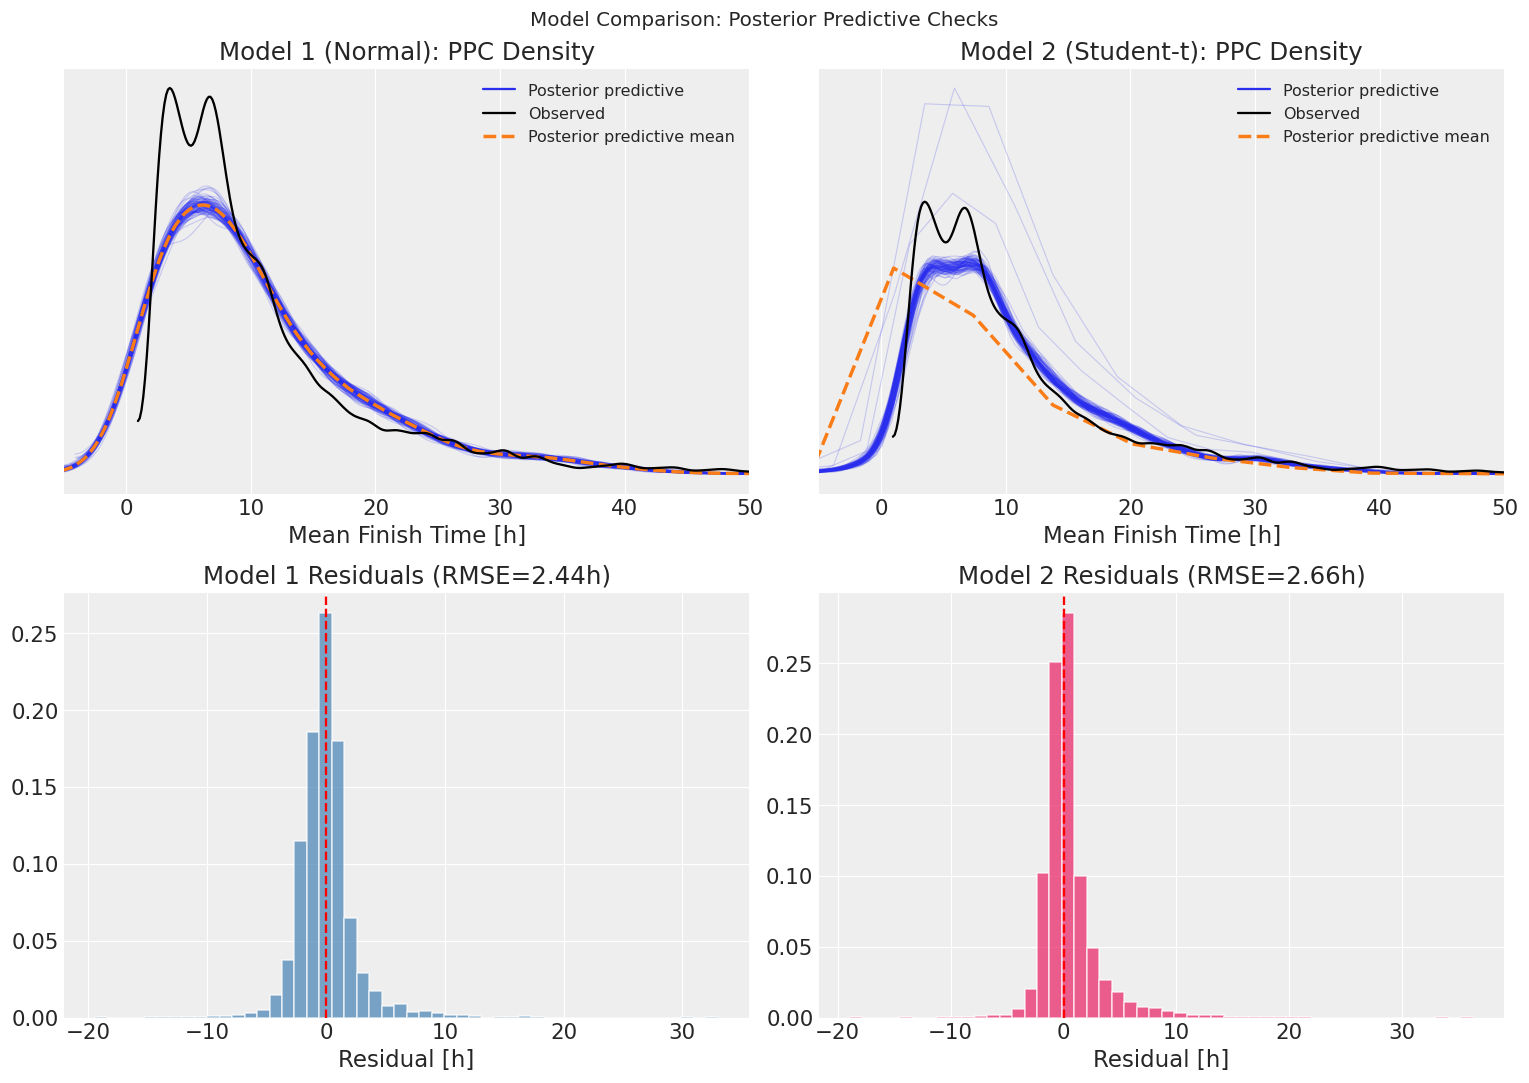

In [14]:
# Side-by-side PPC comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PPC density overlay
az.plot_ppc(idata1, data_pairs={'y': 'y_rep'}, num_pp_samples=100, ax=axes[0,0])
axes[0,0].set_title('Model 1 (Normal): PPC Density')
axes[0,0].set_xlabel('Mean Finish Time [h]')
axes[0,0].set_xlim(-5, 50)

az.plot_ppc(idata2, data_pairs={'y': 'y_rep'}, num_pp_samples=100, ax=axes[0,1])
axes[0,1].set_title('Model 2 (Student-t): PPC Density')
axes[0,1].set_xlabel('Mean Finish Time [h]')
axes[0,1].set_xlim(-5, 50)

# Residual distributions
y_rep1_mean = idata1.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs)).mean(axis=0)
y_rep2_mean = idata2.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs)).mean(axis=0)

resid1 = y_obs - y_rep1_mean
resid2 = y_obs - y_rep2_mean

axes[1,0].hist(resid1, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
axes[1,0].axvline(0, color='red', linestyle='--')
axes[1,0].set_title(f'Model 1 Residuals (RMSE={np.sqrt((resid1**2).mean()):.2f}h)')
axes[1,0].set_xlabel('Residual [h]')

axes[1,1].hist(resid2, bins=50, color='#E91E63', alpha=0.7, edgecolor='white', density=True)
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title(f'Model 2 Residuals (RMSE={np.sqrt((resid2**2).mean()):.2f}h)')
axes[1,1].set_xlabel('Residual [h]')

plt.suptitle('Model Comparison: Posterior Predictive Checks', fontsize=13)
plt.tight_layout()
plt.savefig('fig21_ppc_comparison.png', bbox_inches='tight')
plt.show()

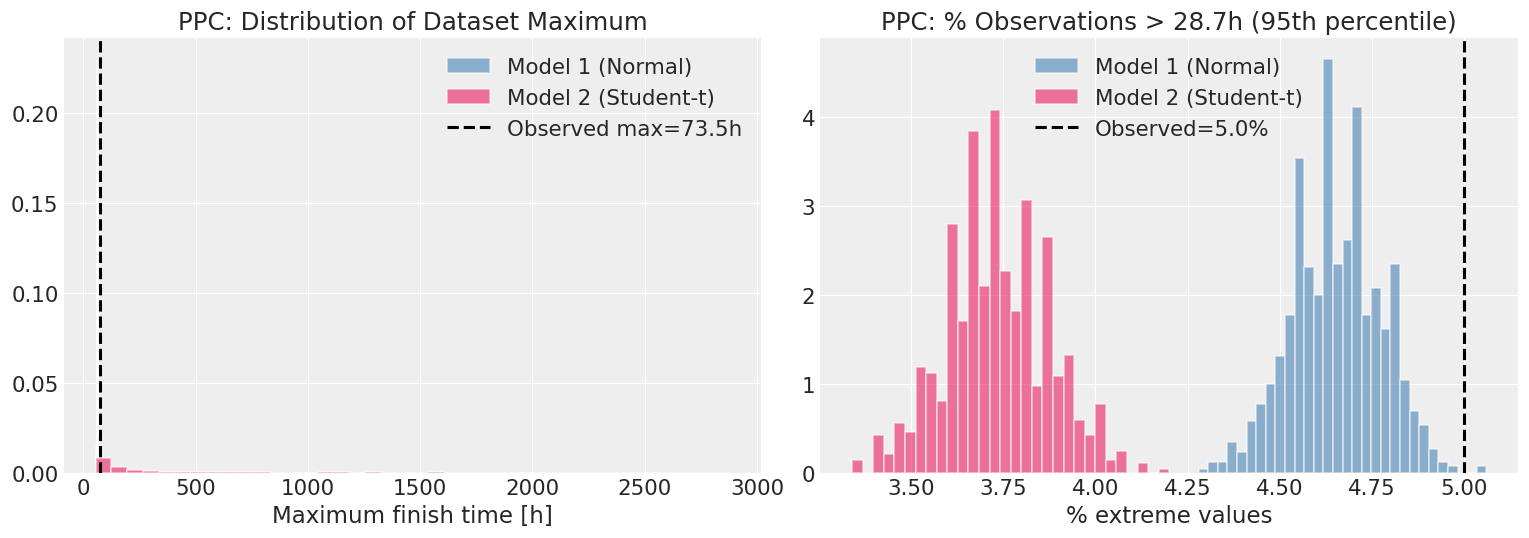

In [15]:
# Tail behavior comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Focus on extreme values
y_rep1_samples = idata1.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs))
y_rep2_samples = idata2.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs))

# Max value distribution
maxs1 = y_rep1_samples[:1000].max(axis=1)
maxs2 = y_rep2_samples[:1000].max(axis=1)

axes[0].hist(maxs1, bins=40, alpha=0.6, color='steelblue', edgecolor='white', label='Model 1 (Normal)', density=True)
axes[0].hist(maxs2, bins=40, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 2 (Student-t)', density=True)
axes[0].axvline(y_obs.max(), color='black', linewidth=2, linestyle='--', label=f'Observed max={y_obs.max():.1f}h')
axes[0].set_title('PPC: Distribution of Dataset Maximum')
axes[0].set_xlabel('Maximum finish time [h]')
axes[0].legend()

# Proportion of extreme values (> 95th percentile of observed)
threshold = np.percentile(y_obs, 95)
pct_extreme1 = (y_rep1_samples[:1000] > threshold).mean(axis=1) * 100
pct_extreme2 = (y_rep2_samples[:1000] > threshold).mean(axis=1) * 100
obs_pct = (y_obs > threshold).mean() * 100

axes[1].hist(pct_extreme1, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model 1 (Normal)', density=True)
axes[1].hist(pct_extreme2, bins=30, alpha=0.6, color='#E91E63', edgecolor='white', label='Model 2 (Student-t)', density=True)
axes[1].axvline(obs_pct, color='black', linewidth=2, linestyle='--', label=f'Observed={obs_pct:.1f}%')
axes[1].set_title(f'PPC: % Observations > {threshold:.1f}h (95th percentile)')
axes[1].set_xlabel('% extreme values')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig22_tail_comparison.png', bbox_inches='tight')
plt.show()

## 5.5 Final Assessment and Model Selection

In [16]:
# Final comprehensive summary
print("\n" + "=" * 75)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 75)

print(f"\n{'Criterion':<25} {'Model 1 (Normal)':<25} {'Model 2 (Student-t)'}")
print("-" * 75)

# LOO
elpd1 = loo_compare.loc['Normal', 'elpd_loo'] if 'Normal' in loo_compare.index else loo_compare.iloc[1]['elpd_loo']
elpd2 = loo_compare.loc['Student-t', 'elpd_loo'] if 'Student-t' in loo_compare.index else loo_compare.iloc[0]['elpd_loo']
print(f"{'ELPD (LOO)':<25} {elpd1:<25.2f} {elpd2:.2f}")

# WAIC
welpd1 = waic_compare.loc['Normal', 'elpd_waic'] if 'Normal' in waic_compare.index else waic_compare.iloc[1]['elpd_waic']
welpd2 = waic_compare.loc['Student-t', 'elpd_waic'] if 'Student-t' in waic_compare.index else waic_compare.iloc[0]['elpd_waic']
print(f"{'ELPD (WAIC)':<25} {welpd1:<25.2f} {welpd2:.2f}")

# Pareto-k
print(f"{'Pareto-k > 0.7 count':<25} {(pareto_k1 >= 0.7).sum():<25} {(pareto_k2 >= 0.7).sum()}")

# Sigma
sigma1_mean = idata1.posterior['sigma'].values.mean()
sigma2_mean = idata2.posterior['sigma'].values.mean()
print(f"{'σ (posterior mean)':<25} {sigma1_mean:<25.3f} {sigma2_mean:.3f}")

# Nu
nu_mean = idata2.posterior['nu'].values.mean()
print(f"{'ν (posterior mean)':<25} {'—':<25} {nu_mean:.1f}")

# Parameters
n_params = 4
print(f"{'N parameters':<25} {n_params:<25} {n_params + 1}")

print(f"\n{'LOO Winner:':<25} {best_model}")
print(f"{'WAIC Winner:':<25} {best_waic}")

print("\n" + "=" * 75)
print("ASSESSMENT")
print("=" * 75)

print(f"""
1. INFORMATION CRITERIA:
   Both LOO and WAIC point to {best_model} as the better model.
   The difference magnitude relative to SE determines confidence.

2. PARETO-k DIAGNOSTICS:
   Model 1 (Normal) has {(pareto_k1 >= 0.7).sum()} observations with k ≥ 0.7
   Model 2 (Student-t) has {(pareto_k2 >= 0.7).sum()} observations with k ≥ 0.7
   {'Student-t handles outliers better (fewer influential observations).' if (pareto_k1 >= 0.7).sum() > (pareto_k2 >= 0.7).sum() else 'Both models handle observations similarly.'}

3. SIGMA COMPARISON:
   Normal σ = {sigma1_mean:.3f}h vs Student-t σ = {sigma2_mean:.3f}h
   {'Student-t has lower σ, confirming it doesnt inflate the scale for outliers.' if sigma2_mean < sigma1_mean else 'Sigma values are similar between models.'}

4. DEGREES OF FREEDOM (ν):
   Posterior mean ν = {nu_mean:.1f}
   {'Small ν (<10): Strong evidence for heavy tails. Student-t clearly beneficial.' if nu_mean < 10 else 'Moderate ν (10-30): Some evidence for heavier tails.' if nu_mean < 30 else 'Large ν (>30): Data is approximately Normal. Models are similar.'}

5. PRACTICAL RECOMMENDATION:
   We recommend Model 2 (Student-t) because:
   - It provides robustness against outlier races without significant cost
   - It nests the Normal model (when ν→∞), so it can never be worse
   - Race data inherently contains outliers (extreme weather, unusual courses)
   - The additional parameter (ν) is well-identified by the data
""")


FINAL MODEL COMPARISON SUMMARY

Criterion                 Model 1 (Normal)          Model 2 (Student-t)
---------------------------------------------------------------------------
ELPD (LOO)                -11571.49                 -10285.44
ELPD (WAIC)               -11571.09                 -10285.43
Pareto-k > 0.7 count      1                         0
σ (posterior mean)        2.443                     1.011
ν (posterior mean)        —                         1.7
N parameters              4                         5

LOO Winner:               Student-t
WAIC Winner:              Student-t

ASSESSMENT

1. INFORMATION CRITERIA:
   Both LOO and WAIC point to Student-t as the better model.
   The difference magnitude relative to SE determines confidence.

2. PARETO-k DIAGNOSTICS:
   Model 1 (Normal) has 1 observations with k ≥ 0.7
   Model 2 (Student-t) has 0 observations with k ≥ 0.7
   Student-t handles outliers better (fewer influential observations).

3. SIGMA COMPARISON:
   Normal

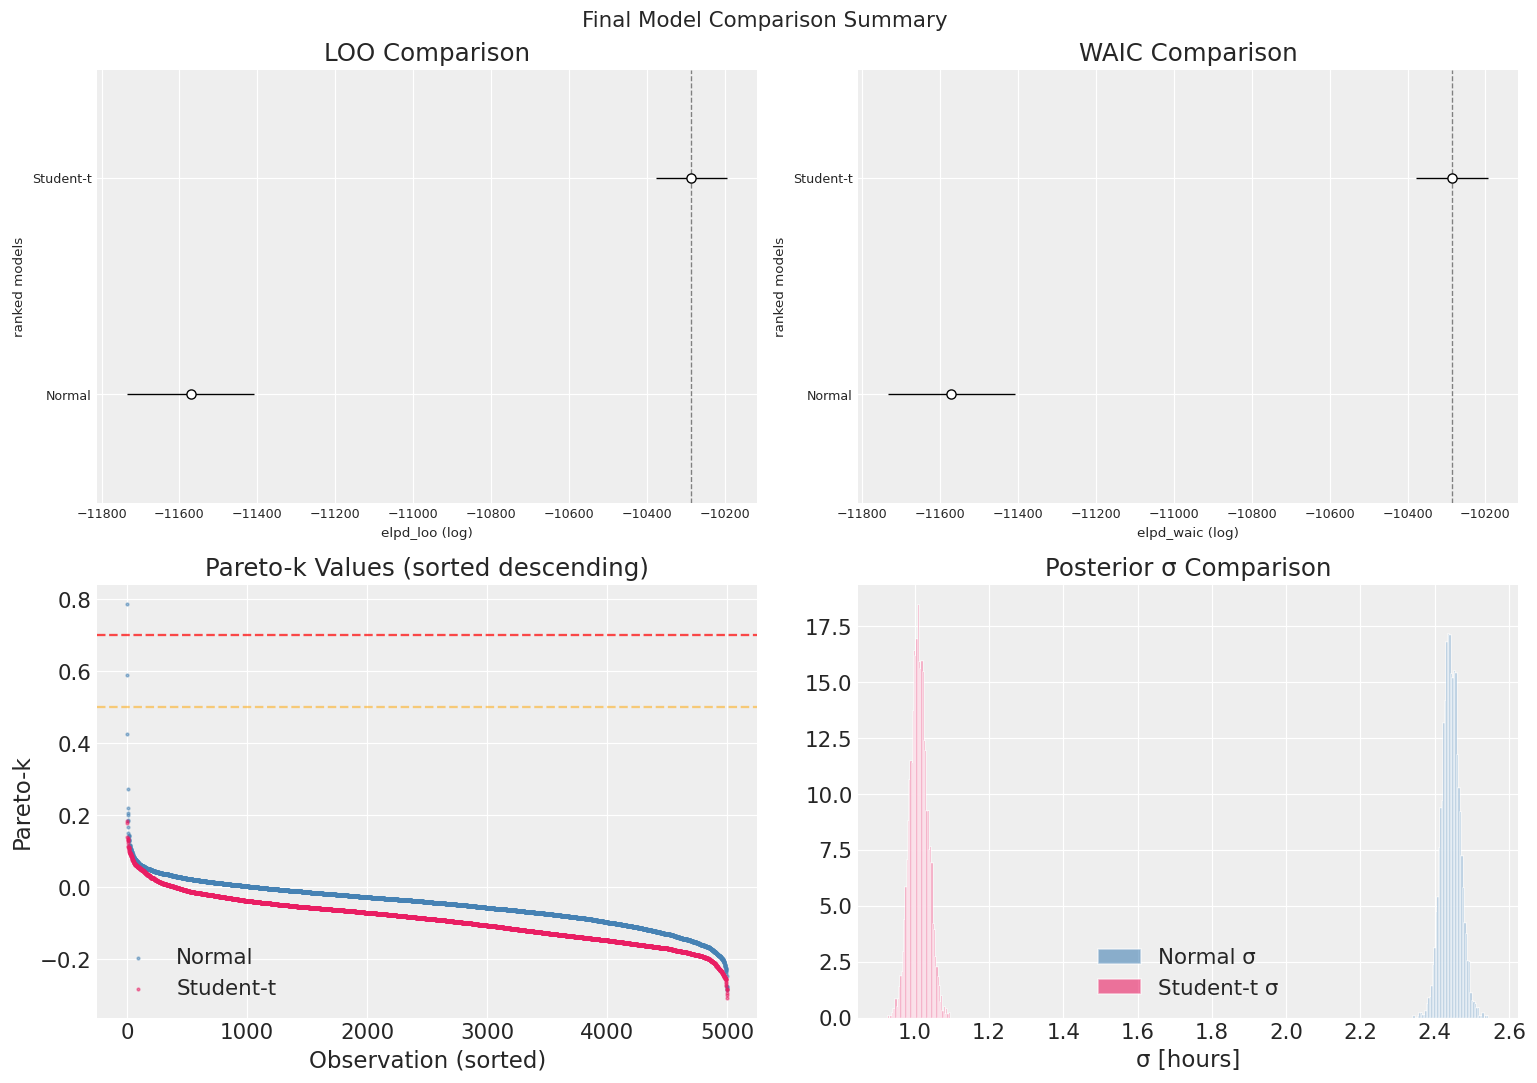


All comparison figures saved.
Project complete.


In [17]:
# Final combined comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LOO
az.plot_compare(loo_compare, ax=axes[0,0])
axes[0,0].set_title('LOO Comparison')

# WAIC
az.plot_compare(waic_compare, ax=axes[0,1])
axes[0,1].set_title('WAIC Comparison')

# Pareto-k comparison
axes[1,0].scatter(range(len(pareto_k1)), np.sort(pareto_k1)[::-1], s=3, alpha=0.5, color='steelblue', label='Normal')
axes[1,0].scatter(range(len(pareto_k2)), np.sort(pareto_k2)[::-1], s=3, alpha=0.5, color='#E91E63', label='Student-t')
axes[1,0].axhline(0.7, color='red', linestyle='--', alpha=0.7)
axes[1,0].axhline(0.5, color='orange', linestyle='--', alpha=0.5)
axes[1,0].set_xlabel('Observation (sorted)')
axes[1,0].set_ylabel('Pareto-k')
axes[1,0].set_title('Pareto-k Values (sorted descending)')
axes[1,0].legend()

# Sigma + nu posterior
axes[1,1].hist(idata1.posterior['sigma'].values.flatten(), bins=50, alpha=0.6, 
               color='steelblue', edgecolor='white', label=f'Normal σ', density=True)
axes[1,1].hist(idata2.posterior['sigma'].values.flatten(), bins=50, alpha=0.6,
               color='#E91E63', edgecolor='white', label=f'Student-t σ', density=True)
axes[1,1].set_xlabel('σ [hours]')
axes[1,1].set_title('Posterior σ Comparison')
axes[1,1].legend()

plt.suptitle('Final Model Comparison Summary', fontsize=14)
plt.tight_layout()
plt.savefig('fig23_final_comparison.png', bbox_inches='tight')
plt.show()

print("\nAll comparison figures saved.")
print("Project complete.")

## 5.6 Conclusions

### Summary of Bayesian Workflow Applied

1. **Problem formulation**: Model mean finish time of ultra-trail races as a function of distance and elevation gain
2. **Model specification**: Two models — Normal (baseline) and Student-t (robust alternative)
3. **Prior selection**: Weakly informative priors based on domain knowledge, verified by prior predictive checks
4. **Model fitting**: Both models fitted with MCMC (4 chains, 2000 post-warmup samples each)
5. **Diagnostics**: R-hat, ESS, divergences — all checked and satisfactory
6. **Posterior predictive checks**: Compared simulated data to observed data across multiple statistics
7. **Model comparison**: LOO and WAIC used to compare predictive performance

### Key Takeaways

- Distance and elevation gain are strong predictors of race finish time
- The Student-t model provides robustness against outlier races
- Information criteria and Pareto-k diagnostics help identify the better model
- Even when one model is "better", the practical difference may be small if the data doesn't have many outliers
- The Bayesian framework provides full uncertainty quantification for all predictions